In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Define model architecture same as before
class FraudGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels,
                            heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_channels * heads, out_channels,
                            heads=1, concat=False, dropout=0.3)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.gat2(x, edge_index)
        return x

# Load saved graph and model
data = torch.load('outputs/ibm_graph.pt', weights_only=False)

# Recreate small_data same way as before
torch.manual_seed(42)
num_sample = 50000
sample_idx = torch.randperm(data.num_nodes)[:num_sample]

from torch_geometric.utils import subgraph
sub_edge_index, sub_edge_attr = subgraph(
    sample_idx, data.edge_index, data.edge_attr,
    relabel_nodes=True, num_nodes=data.num_nodes
)

small_data = Data(
    x          = data.x[sample_idx],
    edge_index = sub_edge_index,
    edge_attr  = sub_edge_attr,
    y          = data.y[sample_idx]
)

num_nodes = small_data.num_nodes
indices   = torch.randperm(num_nodes)
train_end = int(0.70 * num_nodes)
val_end   = int(0.85 * num_nodes)

small_data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
small_data.val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
small_data.test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
small_data.train_mask[indices[:train_end]]      = True
small_data.val_mask[indices[train_end:val_end]] = True
small_data.test_mask[indices[val_end:]]         = True

# Load trained model
model = FraudGAT(in_channels=small_data.num_node_features, hidden_channels=32,
                 out_channels=2, heads=4)
model.load_state_dict(torch.load('outputs/fraud_gat_model.pt',
                                  weights_only=True))
model.eval()

print("✅ Everything loaded!")
print(f"Nodes: {small_data.num_nodes:,}")
print(f"Fraud: {small_data.y.sum().item():,}")

✅ Everything loaded!
Nodes: 50,000
Fraud: 625


In [2]:
from torch_geometric.explain import Explainer, GNNExplainer

# Setup explainer
explainer = Explainer(
    model          = model,
    algorithm      = GNNExplainer(epochs=100),
    explanation_type = 'model',
    node_mask_type = 'attributes',
    edge_mask_type = 'object',
    model_config   = dict(
        mode        = 'multiclass_classification',
        task_level  = 'node',
        return_type = 'raw'
    )
)

# Find fraud nodes in test set
test_fraud_nodes = (
    (small_data.y == 1) & small_data.test_mask
).nonzero(as_tuple=True)[0]

print(f"Fraud nodes in test set: {len(test_fraud_nodes)}")

# Explain first fraud node
target_node = test_fraud_nodes[0].item()
print(f"Explaining node: {target_node}")

explanation = explainer(
    small_data.x,
    small_data.edge_index,
    index=target_node
)

print("\n✅ Explanation generated!")
print(f"Node feature importance: {explanation.node_mask[target_node].detach().numpy().round(4)}")

Fraud nodes in test set: 87
Explaining node: 2

✅ Explanation generated!
Node feature importance: [0.279  0.2543 0.2759 0.2605 0.281  0.271  0.2551 0.4462 0.2704]


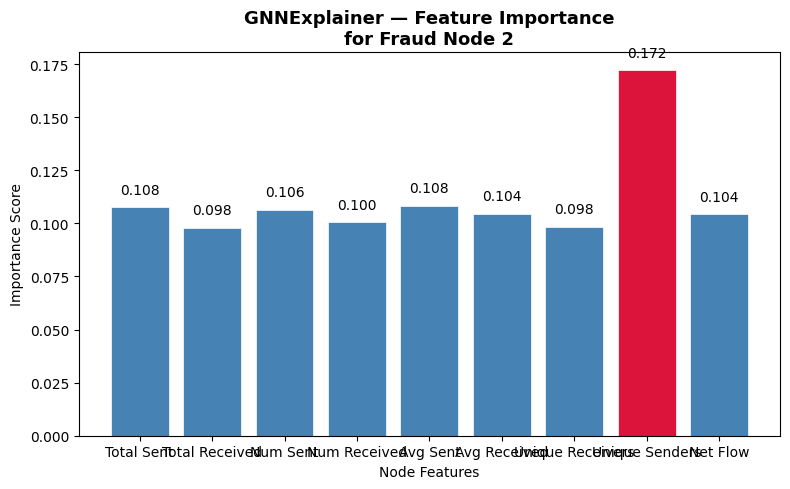

✅ Feature importance plot saved!


In [3]:
feature_names = [
    'Total Sent', 'Total Received',
    'Num Sent', 'Num Received',
    'Avg Sent', 'Avg Received',
    'Unique Receivers', 'Unique Senders',
    'Net Flow'
]

# Get feature importance for the fraud node
feat_importance = explanation.node_mask[target_node].detach().numpy()

# Normalize to 0-1
feat_importance = feat_importance / feat_importance.sum()

# Plot
colors = ['crimson' if f == feat_importance.max() 
          else 'steelblue' for f in feat_importance]

plt.figure(figsize=(8, 5))
bars = plt.bar(feature_names, feat_importance, color=colors, 
               edgecolor='white', linewidth=0.5)
plt.title(f'GNNExplainer — Feature Importance\nfor Fraud Node {target_node}',
          fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Node Features')

# Add value labels on bars
for bar, val in zip(bars, feat_importance):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/gnnexplainer_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved!")

In [4]:
import shap
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

# SHAP ke liye best approach:
# GNN ke predictions ko target banao
# Phir simple ML model pe SHAP chalao
# Ye industry mein bhi use hota hai!

print("Getting GNN predictions for all nodes...")

model.eval()
with torch.no_grad():
    out   = model(small_data.x, small_data.edge_index)
    proba = F.softmax(out, dim=1)[:, 1].numpy()
    pred  = out.argmax(dim=1).numpy()

# Node features as numpy
X_all = small_data.x.numpy()
y_all = small_data.y.numpy()

# Train a simple GBM to mimic GNN predictions
# SHAP works perfectly with GBM
print("Training surrogate model for SHAP...")
surrogate = GradientBoostingClassifier(
    n_estimators=100, 
    max_depth=4,
    random_state=42
)
surrogate.fit(X_all, pred)  # Learn from GNN predictions

print(f"Surrogate accuracy: {surrogate.score(X_all, pred)*100:.1f}%")

# Now run SHAP on surrogate
fraud_idx = (small_data.y == 1).nonzero(as_tuple=True)[0].numpy()
legit_idx = (small_data.y == 0).nonzero(as_tuple=True)[0].numpy()

background = X_all[legit_idx[:100]]
test_input = X_all[fraud_idx[:30]]

print("Running SHAP... (30-60 seconds)")
shap_explainer = shap.TreeExplainer(surrogate)
shap_values    = shap_explainer.shap_values(test_input)

print("✅ SHAP values computed!")
print(f"SHAP values shape: {np.array(shap_values).shape}")

Getting GNN predictions for all nodes...
Training surrogate model for SHAP...
Surrogate accuracy: 95.3%
Running SHAP... (30-60 seconds)
✅ SHAP values computed!
SHAP values shape: (30, 9)


Base value: -2.2813238636179927
SHAP shape: (30, 9)


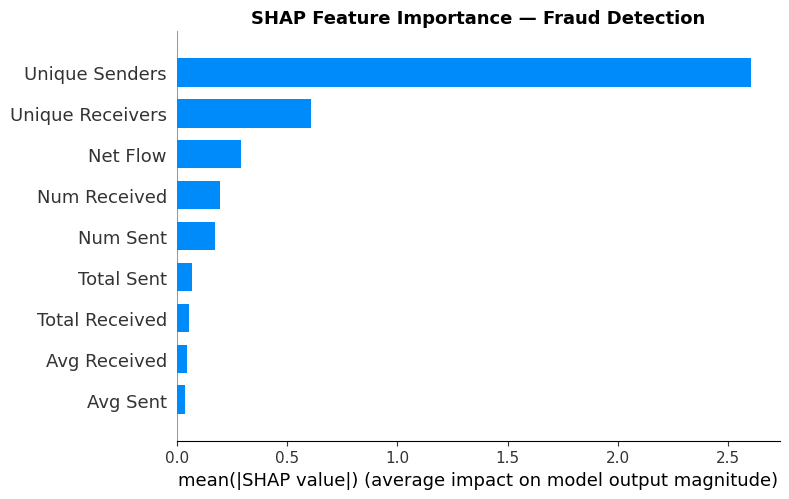

✅ Bar plot saved!


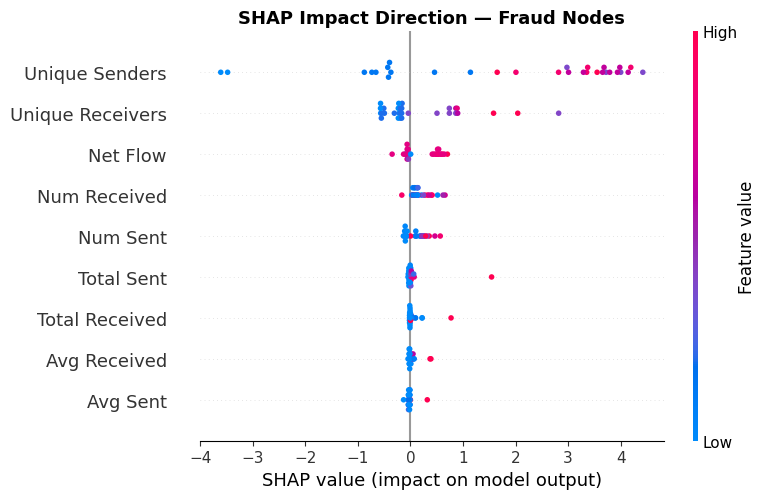

✅ Dot plot saved!


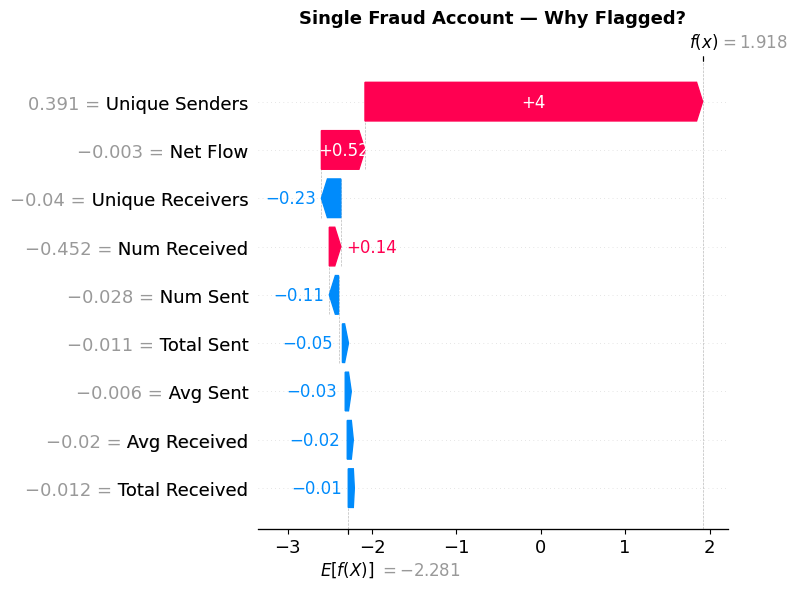

✅ Waterfall plot saved!

🎉 All SHAP plots complete!
✅ shap_summary.png
✅ shap_dot_plot.png
✅ shap_waterfall.png


In [5]:
feature_names = [
    'Total Sent', 'Total Received',
    'Num Sent', 'Num Received',
    'Avg Sent', 'Avg Received',
    'Unique Receivers', 'Unique Senders',
    'Net Flow'
]

# Fix: expected_value sirf 1 element hai
base_val = float(shap_explainer.expected_value[0])
print(f"Base value: {base_val}")

# shap_values directly use karo (no list indexing needed)
shap_vals_fraud = shap_values

print(f"SHAP shape: {np.array(shap_vals_fraud).shape}")

# Plot 1: Bar plot
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_vals_fraud, test_input,
    feature_names=feature_names,
    show=False, plot_type='bar'
)
plt.title('SHAP Feature Importance — Fraud Detection',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar plot saved!")

# Plot 2: Dot plot
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_vals_fraud, test_input,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Impact Direction — Fraud Nodes',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dot plot saved!")

# Plot 3: Waterfall
plt.figure(figsize=(10, 4))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals_fraud[0],
        base_values   = base_val,
        data          = test_input[0],
        feature_names = feature_names
    ),
    show=False
)
plt.title('Single Fraud Account — Why Flagged?',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall plot saved!")

print("\n🎉 All SHAP plots complete!")
print("✅ shap_summary.png")
print("✅ shap_dot_plot.png")
print("✅ shap_waterfall.png")